<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Astrofisica-moderna/proyecto_comp1_astromod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EFECTO DE COLIMACION Y DOPPLER RELATIVISTA**
<br>

#### **Astrofisica moderna:** Proyecto computacional 1
##### Prof. German Chaparro Molano

> Juan Manuel Cardenas

<br>

In [ ]:
# librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files
%matplotlib inline

Una nave espacial que puede ir a velocidades relativistas (v = 0.4c) emprende un viaje desde la Tierra en la direccion del centro de la constelacion del Can Mayor. Utilizando los datos de cma data.csv

In [ ]:
# carga rapida de archivos (seleccionar los 2: colors.csv y cma_data.csv)
uploaded = files.upload()

Saving colors.csv to colors.csv
Saving cma_data.csv to cma_data.csv


In [ ]:
# posiciones, magnitudes y longitud de onda "principal" de estrellas en la constelación
df = pd.read_csv("cma_data.csv")

# correspondencia entre longitud de onda en nm y código RGB en hex
cinf = pd.read_csv('colors.csv')

In [ ]:
# Parametros importantes

c = 3e8         # [m/s^2] velocidad luz
v = 0.4*c       # velocidad nave
rad = np.pi/180 # factor [deg] a [rads]
gamma = lambda v: 1/((1-(v/c)**2)**0.5) # factor de lorentz


**Funciones a emplear**:

Se emplearon funciones sobre la colimacion relativista, el efecto dopler relativista general vistas en clase, y algunas funciones de trigonometria esferica de Astronomia de Posicion.

In [ ]:
# Funcion colimacion relativista
def colimacion_relativ(theta_p, v): # [rad, m/s^2]

  theta = np.arctan( np.sin(theta_p) / (gamma(v)*(np.cos(theta_p) + v/c )) )
  return theta # [rad]


# Teoremas de Trigonomtria Esferica
def cos_lados(a,b,C):  # teorema de coseno para lados (c)
  return np.arccos( np.cos(a)*np.cos(b) + np.sin(a)*np.sin(b)*np.cos(C) )

def tma_sin(a,c,C):    # teorema de seno, para angulo (A)
  return np.arcsin( (np.sin(C)*np.sin(a))/np.sin(c) )


Funcion para el calculo de los nuevos angulos vistos por la nave moviendose a velocidad relativista

In [ ]:
def nuevos_angulos(δs,αs,  δc,αc, v): # estrella(δ,α), centro(δ,α), velocidad

  # angulos entrantes en [deg]
  # se toma triangulo estrella(A), centro(B), PNC(C)
  a = ( np.pi/2 - δc*rad )        # [rads]
  b = ( np.pi/2 - δs*rad )        # [rads]
  C = np.abs( αc - αs )*rad       # abs garantiza para cualquier long(+,-)

  if C < np.pi:                   # condicion angulos y lados deben ser <180
    c = cos_lados(a,b,C)          # [rads] tma coseno de lados

  else:
    C_con = 2*np.pi - C           # conjugado de c
    c = cos_lados(a,b,C_con)      # [rads]

  """ la colimacion se aplica sobre el angulo medido desde la direccion a la
      que se dirige la nave(en este caso es el "centro" de la constelacion)
      hasta el objeto a estudiar(estrellas), luego el efecto de colimacion se
      manifiesta en el angulo (star-tierra-centro), no directamente en los
      angulos RA y DEC iniciales"""

  c_new = colimacion_relativ(c, v) # [rads] angulo colimado


  # Calculo nueva RA
  A = tma_sin(a,c,C)           # [rads] angulo (PNC,star,center)
  C_new = tma_sin(c_new, a, A) # [rads]

  if αc < αs: # si RA star cambia respecto al centro, el triangulo cambia
    α_new = np.abs(C_new/rad + αc)

  else: α_new = np.abs(αc - C_new/rad)


  # Calculo nueva DEC
  if δc < δs :
    A_sup = np.pi - A # tomando el suplementario de A

    # otras relaciones de trig esferica
    nume = np.cos(c_new) - (np.cos(a))**2/(np.cos(c_new))
    deno = np.sin(a)*np.cos(C_new) - np.cos(a)*np.tan(c_new)*np.cos(A_sup)
    b_new = np.abs(np.arcsin( nume/deno ))
    δ_new = ((b_new/rad) - 90) # estan en hemisferio sur celeste

  else:
    a_new = cos_lados(b, c-c_new, A)/rad # [deg]
    δ_new = 90 - a_new # [deg]

  return α_new, δ_new, c_new # [deg,deg,rad]

In [ ]:
# RA(α) Y DEC(δ) estrellas
αs = np.array(df['ra'])
δs = np.array(df['dec'])

# RA(α) Y DEC(δ) centro de la constelacion
αc = df.ra.mean()
δc = df.dec.mean()

# aplicando la colimacion relativista
α_new, δ_new, theta_new = np.vectorize(nuevos_angulos)(δs,αs, δc,αc, v)


1. (1.5 pt) Haga una grafica RA/DEC que muestre el efecto de colimacion relativistico visto desde la nave para cada estrella en la constelacion. En la grafica se deben ver las posiciones originales de las estrellas vs las observadas desde la nave.


In [ ]:
# colores vistos desde la tierra
lamround = 5*round(df.lam/5)
colors = [cinf.hex[cinf.lamc==i].iloc[0] for i in lamround]

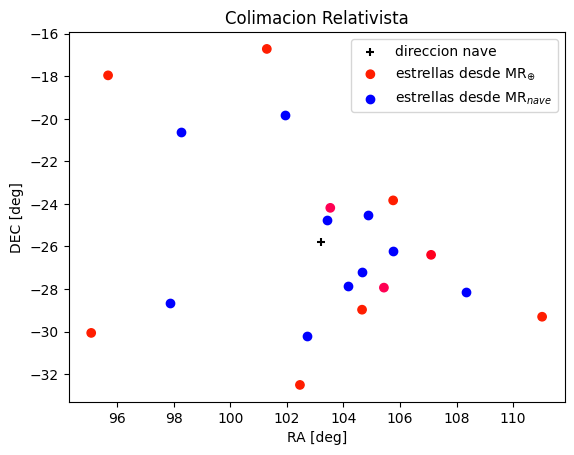

In [ ]:
# grafica colimacion relativista
plt.scatter(αc, δc, c='k', marker='+', label='direccion nave')
plt.scatter(αs, δs, c=colors, label=r'estrellas desde MR$_{\oplus}$')
plt.scatter(α_new, δ_new, c='b', label=r'estrellas desde MR$_{nave}$')
plt.title('Colimacion Relativista')
plt.xlabel('RA [deg]')
plt.ylabel('DEC [deg]')
plt.legend()
plt.show()

2. (1.5 pt) Haga una grafica RA/DEC que muestre el corrimiento Doppler relativistico de la longitud de onda (color) visto desde la nave para cada estrella en la constelacion. Recuerde tener en cuenta el  ́angulo entre la direcci ́on del desplazamiento de la nave y la ubicaci ́on de cada estrella. Para
ilustrar el color, (guıese con el notebook CMA.ipynb adjunto, para el que se necesita el archivo colors.csv.)

3. (0.5 pt) Una las dos graficas para evidenciar los efectos de colimacion y Doppler relativista al mismo tiempo.



In [ ]:
# funcion para calculo efecto doppler relativistico (general)
def doppler_general(lambda_em, theta, v):

  lambda_obs = lambda_em * gamma(v) * (1-v/c*np.cos(theta))
  return lambda_obs


# redondeando lambda y tomando el color asociado
def color_asociado(lambda_obs):

  df_color = pd.DataFrame({'lam': lambda_obs})
  lamdaobs_round = 5*round(df_color.lam/5)
  colors = [cinf.hex[cinf.lamc==i].iloc[0] for i in lamdaobs_round]
  return colors

In [ ]:
# encontrando la longitud observada
lambda_em = np.array(df['lam']) # [nm]
lambda_obs = np.vectorize(doppler_general)(lambda_em, theta_new, v) # [nm]
colors2 = color_asociado(lambda_obs)

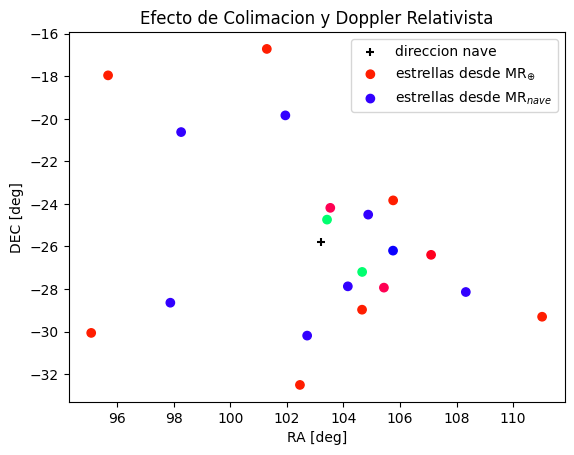

In [ ]:
# grafica colimacion + doppler relativista
plt.scatter(αc, δc, c='k', marker='+', label='direccion nave')
plt.scatter(αs, δs, c=colors, label=r'estrellas desde MR$_{\oplus}$')
plt.scatter(α_new, δ_new, c=colors2, label=r'estrellas desde MR$_{nave}$')
plt.title('Efecto de Colimacion y Doppler Relativista')
plt.xlabel('RA [deg]')
plt.ylabel('DEC [deg]')
plt.legend()
plt.show()

4. (0.5 pt) Sobre la misma grafica del punto 3. grafique la colimacion/efecto Doppler para v = 0.1c, 0.2c, 0.3c.


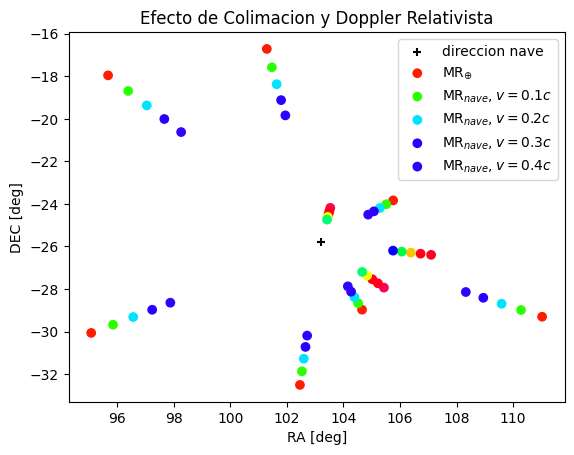

In [ ]:
vel = np.array([0.1*c, 0.2*c, 0.3*c, 0.4*c])
v_str = ['0.1c', '0.2c', '0.3c', '0.4c']

plt.scatter(αc, δc, c='k', marker='+', label='direccion nave')
plt.scatter(αs, δs, c=colors, label=r'MR$_{\oplus}$')
plt.title('Efecto de Colimacion y Doppler Relativista')
plt.xlabel('RA [deg]')
plt.ylabel('DEC [deg]')


for i,vi in enumerate(vel): # sobre cada velocidad

  # aplicando efecto colimacion
  α_new, δ_new, theta_new = np.vectorize(nuevos_angulos)(δs,αs, δc,αc, vi)

  # aplicando efecto doppler a lambda
  lambda_obs = np.vectorize(doppler_general)(lambda_em, theta_new, vi) # [nm]

  # obteniendo colores asociados a lambda
  colors_i = color_asociado(lambda_obs)

  # graficando
  plt.scatter(α_new, δ_new, c=colors_i, label=rf'MR$_{{nave}}, v={v_str[i]}$')

plt.legend()
plt.show()




5. (1 pt) Procedimiento: Dependiendo de como se hagan los calculos de los puntos anteriores el procedimiento se calificara con la siguiente rubrica:
* 1 pt si se hace el calculo exacto de loś ́angulos,
* 0.5 si se hace el calculo aproximando una malla cartesiana para los  ́angulos y justificando la aproximacion.
* 0 pt si no se justifica o si se justifica incorrectamente.

Importante: Debe adjuntar el notebook de Jupyter en formato .ipynb y en .pdf (exportado/impreso).